In [3]:
# Imports
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Configuration
Set your CSV path and output directory here. Optionally filter columns using a regex (e.g., one marker). Choose error metric (`sem` or `sd`).

In [ ]:
#This script takes processed and filtered data from the pipeline and allows you to plot the data as a swarm plot. 

#The script takes a csv file as an input. In the csv, each column should be a condition plus a replicate e.g ('WT_R1' or 'WT_rep1'). It can deal with different nomenclatures for replicates 
#but you must be consistent between them). The rows are the values of individual cells or nuclei. Condition names should be consistent, apart from the replicate name, as the script will parse this information for
#grouping different conditions together.

#You can specify the conditions that you want to plot and the order in which they should be plotted.

#The output plot takes every data point (rows) and plots them a swarm plot (scatterplot). The means for each replicate are grouped together based on their condition and plotted as dots on top.
# The overall mean of replicates is plotted as a red line on plot.

#It is possible to plot error bars as either standard deviation or standard error of the mean, if you activate that option.

In [ ]:
# Specify your input folder
csv_path = "input_directory/input.csv"    

# Path to your input CSV file
output_dir = "out_directory/plots" # Output directory for figures (will be created if it doesn’t exist)

# If you want to filter columns (e.g., only a specific marker), set a regex here.
# Leave as None to include all numeric condition/replicate columns.
column_include_regex = None      # Example: r"^H3K9ac_.*"

# Choose error metric for overall mean error bars across replicate means: "sem" or "sd"
error_metric = "sd"

# Point transparency for raw datapoints in the swarm. 
point_alpha = 0.35

# Random seed for reproducible jitter
rng_seed = 42

# --- Condition selection & ordering ---
# Specify the exact order of teh conditions that you want as a list
condition_order = [""]

# 2) OR a subset list (alphabetical unless condition_order is set):
conditions_subset = None        # e.g., ['WT', 'KAT2A_KO']
# 3) OR a regex to include:
conditions_regex = None         # e.g., r'^(WT|KAT2A_KO)$'

# --- Axis limits (set to None to auto) ---
y_min = -0.1   # e.g., 0
y_max = 2.5  # e.g., 2.0

# --- Axis labels ---
x_label = "Condition"
y_label = "Nuclear KAT2B fluorescence (AU)"

# --- Axes sizing (plotting area only) ---
axes_height_cm = 12.0
axes_width_per_condition_cm = 2.5

# --- Dot/line sizes & styling ---
strip_dot_size = 3              # seaborn strip point size (points)
rep_mean_dot_size = 43          # matplotlib scatter 's' (points^2) for replicate means
overall_mean_linewidth = 2.0    # red mean line width
error_linewidth = 1.0           # error bar line width
point_alpha = 0.4         # transparency for raw datapoints
jitter_width_for_means = 0.20   # horizontal spread for replicate-means if multiple reps

# Show vertical error bars (SEM/SD across replicate means)
show_overall_errorbars = False

# Random seed (for demo data or any randomness)
rng_seed = 42


# --- Dot sizes ---
swarm_dot_size = 8      # individual datapoints in swarm
rep_mean_dot_size = 43      # per-replicate mean markers
# (overall mean is a line, not a dot, but we still use a linewidth)
overall_mean_linewidth = 1.5
# Error bar line width
error_linewidth = 1.5

# Jitter for swarm
jitter_width = 0.25

# Show vertical error bars (SEM/SD) for the overall mean?
show_overall_errorbars = False


## Helper functions

In [ ]:
#Helper functions to parse conditions and replicates together and plot them together, and calculate statistics if you have the error bars call set to True.

#Helper functions to define figure size, so that the figure size adapts and maintains the same dimensions when there are different numbers of input conditions.


# Helper functions
def parse_condition_and_rep(col_name: str):
    """
    Parse columns like:
      Condition_R1, Condition_R2, Condition_rep1, Condition_rep02
    Returns (condition, replicate_label)
    """
    m = re.match(r"^(?P<cond>.+?)_(?:R|rep)?(?P<rep>\d+)$", col_name, flags=re.IGNORECASE)
    if m:
        return m.group("cond"), m.group("rep")
    else:
        # No replicate suffix → treat as single replicate "1"
        return col_name, "1"

def collect_by_condition(df: pd.DataFrame, col_filter_regex=None):
    """
    Returns:
      cond_to_values: dict[condition] -> concatenated values across replicates (np.array)
      cond_to_reps:   dict[condition] -> dict[rep_label] -> np.array values
    """
    if col_filter_regex:
        keep_cols = [c for c in df.columns if re.search(col_filter_regex, c)]
    else:
        keep_cols = list(df.columns)

    cond_to_reps = {}
    for col in keep_cols:
        vals = pd.to_numeric(df[col], errors="coerce").dropna().values
        if vals.size == 0:
            continue
        cond, rep = parse_condition_and_rep(col)
        cond_to_reps.setdefault(cond, {})
        cond_to_reps[cond].setdefault(rep, np.array([], dtype=float))
        cond_to_reps[cond][rep] = np.concatenate([cond_to_reps[cond][rep], vals.astype(float)])

    cond_to_values = {
        cond: np.concatenate(list(rep_map.values()))
        for cond, rep_map in cond_to_reps.items() if rep_map
    }
    return cond_to_values, cond_to_reps

def compute_overall_stats(cond_to_reps: dict, metric: str = "sem"):
    """
    Compute replicate means per condition, then overall mean of those replicate means,
    and error as SEM or SD across replicate means.
    """
    cond_to_rep_means = {}
    cond_to_overall_mean = {}
    cond_to_overall_err = {}

    for cond, rep_map in cond_to_reps.items():
        rep_means = [np.mean(v) for v in rep_map.values() if len(v) > 0]
        if len(rep_means) == 0:
            continue
        rep_means = np.array(rep_means, dtype=float)
        cond_to_rep_means[cond] = rep_means
        overall_mean = float(np.mean(rep_means))
        if len(rep_means) > 1:
            sd = float(np.std(rep_means, ddof=1))
        else:
            sd = 0.0
        if metric.lower() == "sem":
            err = sd / np.sqrt(len(rep_means)) if len(rep_means) > 0 else 0.0
        else:
            err = sd
        cond_to_overall_mean[cond] = overall_mean
        cond_to_overall_err[cond] = float(err)
    return cond_to_rep_means, cond_to_overall_mean, cond_to_overall_err

def cm_to_inches(cm):
    return cm / 2.54

def create_figure_with_axis_size(ax_width_cm, ax_height_cm,
                                 left_margin_cm=2.0, right_margin_cm=0.8,
                                 bottom_margin_cm=2.0, top_margin_cm=0.8):
    """
    Create a matplotlib figure and axes such that the **axes** (plotting area)
    are ax_width_cm x ax_height_cm. Margins are in cm. Returns (fig, ax).
    """
    def cm_to_in(cm):
        return cm / 2.54
    ax_w_in = cm_to_in(ax_width_cm)
    ax_h_in = cm_to_in(ax_height_cm)
    lm_in = cm_to_in(left_margin_cm)
    rm_in = cm_to_in(right_margin_cm)
    bm_in = cm_to_in(bottom_margin_cm)
    tm_in = cm_to_in(top_margin_cm)
    fig_w_in = lm_in + ax_w_in + rm_in
    fig_h_in = bm_in + ax_h_in + tm_in

    fig = plt.figure(figsize=(fig_w_in, fig_h_in))
    ax = fig.add_axes([
        lm_in / fig_w_in,
        bm_in / fig_h_in,
        ax_w_in / fig_w_in,
        ax_h_in / fig_h_in,
    ])
    return fig, ax

def finalize_axis(
    ax, *,
    conditions,
    x_label, y_label,
    y_min=None, y_max=None,
    spine_width=2, tick_len=4, tick_w=1
):
    # X ticks & labels
    x_positions = np.arange(1, len(conditions) + 1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(conditions, rotation=45, ha='right')
    ax.set_xlim(0.5, len(conditions) + 0.5)

    # Y label and (re)apply limits LAST, then freeze autoscale
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if (y_min is not None) or (y_max is not None):
        cur_bottom, cur_top = ax.get_ylim()
        bottom = y_min if y_min is not None else cur_bottom
        top    = y_max if y_max is not None else cur_top
        ax.set_ylim(bottom=bottom, top=top)
    ax.set_autoscale_on(False)   # <- prevents later artists from changing limits

    # Only left & bottom spines visible
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_linewidth(spine_width)
    ax.spines['bottom'].set_linewidth(spine_width)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Ticks only on left/bottom; style ticks
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(axis='both', which='both', length=tick_len, width=tick_w, direction='out')


## Load data and compute stats

In [6]:
# Load data and compute stats
df = pd.read_csv(csv_path)

cond_to_values, cond_to_reps = collect_by_condition(df, column_include_regex)
all_conditions = list(cond_to_values.keys())

if len(all_conditions) == 0:
    raise RuntimeError("No usable numeric condition columns found. Check your CSV and 'column_include_regex'.")

# Start from all parsed conditions
conditions = all_conditions[:]

# Apply subset list if provided
if conditions_subset is not None:
    conditions = [c for c in conditions_subset if c in cond_to_values]

# Apply regex subset if provided
if conditions_regex is not None:
    _pat = re.compile(conditions_regex)
    conditions = [c for c in conditions if _pat.search(c)]

# Apply explicit order if provided (also acts as subset)
if condition_order is not None:
    conditions = [c for c in condition_order if c in cond_to_values and c in conditions]
else:
    # default alphabetical for stability
    conditions = sorted(conditions)

if len(conditions) == 0:
    raise RuntimeError('After applying subset/order filters, no conditions remain to plot.')

# Overall stats (based on replicate means)
rep_means, overall_means, overall_errs = compute_overall_stats(cond_to_reps, error_metric)


## Swarm-style plot (grey points, black replicate means, red overall mean ± error)

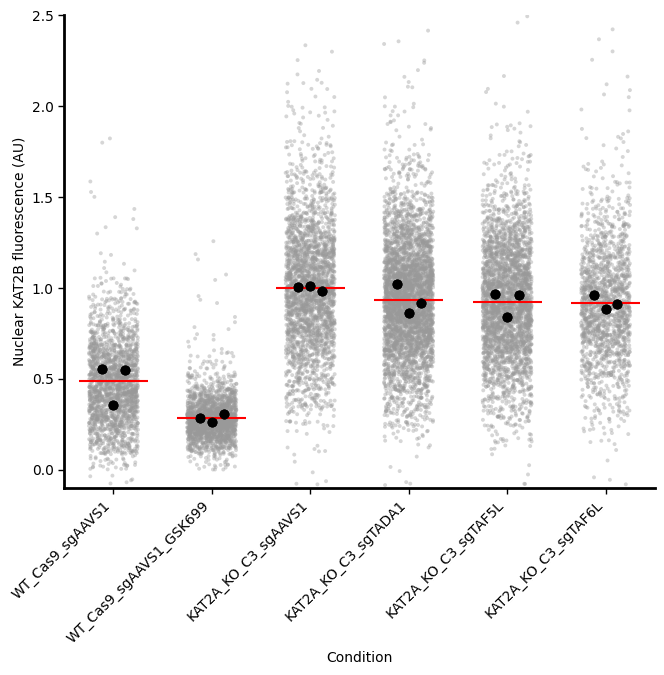

In [ ]:
# Plot as a swarm plot.
from matplotlib.collections import LineCollection

np.random.seed(rng_seed)
ax_w_cm = axes_width_per_condition_cm * len(conditions)
ax_h_cm = axes_height_cm
fig1, ax1 = create_figure_with_axis_size(ax_w_cm, ax_h_cm)

# Raw datapoints (jittered)
for i, cond in enumerate(conditions, start=1):
    y = cond_to_values[cond]
    x = i + (np.random.rand(len(y)) - 0.5) * 2 * jitter_width
    ax1.scatter(x, y, alpha=point_alpha, s=swarm_dot_size, edgecolors='none', c='0.6', zorder=2)

    # Per-replicate means (black dots)
    reps = cond_to_reps[cond]
    rep_keys = sorted(reps.keys())
    offsets = np.linspace(-0.12, 0.12, num=len(rep_keys)) if len(rep_keys) > 1 else [0.0]
    for off, rk in zip(offsets, rep_keys):
        m = np.mean(reps[rk])
        ax1.scatter(i + off, m, s=rep_mean_dot_size, c='black', edgecolors='black', linewidths=0.6, zorder=4)

# ---
mean_segments = []
err_segments = []
for i, cond in enumerate(conditions, start=1):
    y_bar = overall_means[cond]
    mean_segments.append([(i - 0.35, y_bar), (i + 0.35, y_bar)])
    if show_overall_errorbars and overall_errs.get(cond, 0.0) > 0:
        err_segments.append([(i, y_bar - overall_errs[cond]), (i, y_bar + overall_errs[cond])])

if mean_segments:
    ax1.add_collection(LineCollection(mean_segments, colors='red',
                                      linewidths=overall_mean_linewidth, zorder=4, capstyle='butt'))
if err_segments:
    ax1.add_collection(LineCollection(err_segments, colors='red',
                                      linewidths=error_linewidth, zorder=4, capstyle='butt'))

# --- Now overlay replicate mean dots on top ---
for i, cond in enumerate(conditions, start=1):
    reps = cond_to_reps[cond]
    rep_keys = sorted(reps.keys())
    offsets = np.linspace(-0.12, 0.12, num=len(rep_keys)) if len(rep_keys) > 1 else [0.0]
    for off, rk in zip(offsets, rep_keys):
        m = np.mean(reps[rk])
        ax1.scatter(i + off, m, s=rep_mean_dot_size, c='black',
                    edgecolors='black', linewidths=0.6, zorder=5)  # <- higher zorder


# X axis ticks and labels
x_positions = np.arange(1, len(conditions) + 1)
ax1.set_xticks(x_positions)
ax1.set_xticklabels(conditions, rotation=45, ha='right')

# Y axis ticks and labels
ax1.yaxis.set_ticks_position('left')
ax1.xaxis.set_ticks_position('bottom')
ax1.tick_params(axis='both', which='both', length=4, width=1, direction='out')

# Axis labels
ax1.set_xlabel(x_label)
ax1.set_ylabel(y_label)

# --- Axis cosmetics: only left & bottom spines, with ticks ---
# Make sure only bottom and left spines are visible
ax1.spines['left'].set_visible(True)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_linewidth(2)    # adjust thickness
ax1.spines['bottom'].set_linewidth(2)

# Remove top and right completely
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Ensure ticks only on bottom and left
ax1.yaxis.set_ticks_position('left')
ax1.xaxis.set_ticks_position('bottom')

# Set tick parameters (length, width, direction)
ax1.tick_params(axis='both', which='both', length=4, width=1, direction='out')

finalize_axis(
    ax1,                             # <- or ax0/ax2/ax3
    conditions=conditions,
    x_label=x_label,
    y_label=y_label,
    y_min=y_min,
    y_max=y_max,
    spine_width=2,                   # tweak to taste
    tick_len=4,
    tick_w=1
)



plt.show()


## Box plot (black boxes/whiskers, black replicate means, red overall mean ± error)

## Save figures (PNG + PDF)

In [ ]:
# Save figures (PNG + PDF)
if output_dir:
    os.makedirs(output_dir, exist_ok=True)
    fig1.savefig(os.path.join(output_dir, 'swarm_plot_PLOT_FINAL.png'), dpi=300, bbox_inches='tight')
    fig1.savefig(os.path.join(output_dir, 'swarm_plot_PLOT_FINAL.pdf'), bbox_inches='tight')
    print(f'Figures saved in: {output_dir}')

